## Treating the Barriers

In [4]:
from samplomatic.transpiler import generate_boxing_pass_manager
from qiskit import QuantumCircuit

qc = QuantumCircuit(4,4)

qc.h(range(4))
qc.cz(0,1)
qc.barrier()
qc.cz(2,3)
qc.barrier()
qc.measure(range(4),range(4)) 

In [5]:
qc.draw()

┌───┐    ░     ░ ┌─┐         
q_0: ┤ H ├─■──░─────░─┤M├─────────
     ├───┤ │  ░     ░ └╥┘┌─┐      
q_1: ┤ H ├─■──░─────░──╫─┤M├──────
     ├───┤    ░     ░  ║ └╥┘┌─┐   
q_2: ┤ H ├────░──■──░──╫──╫─┤M├───
     ├───┤    ░  │  ░  ║  ║ └╥┘┌─┐
q_3: ┤ H ├────░──■──░──╫──╫──╫─┤M├
     └───┘    ░     ░  ║  ║  ║ └╥┘
c: 4/══════════════════╩══╩══╩══╩═
                       0  1  2  3

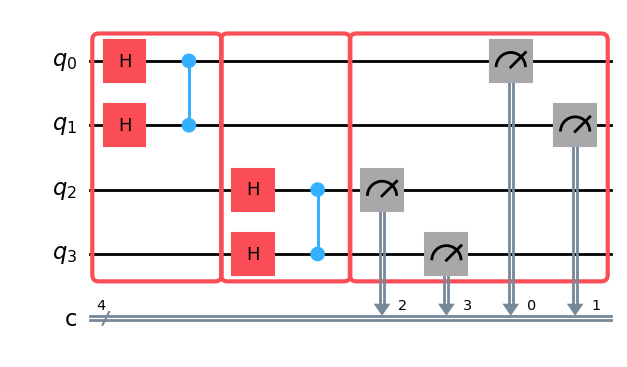

In [11]:
bpm = generate_boxing_pass_manager()

tqc = bpm.run(qc)
tqc.draw('mpl')

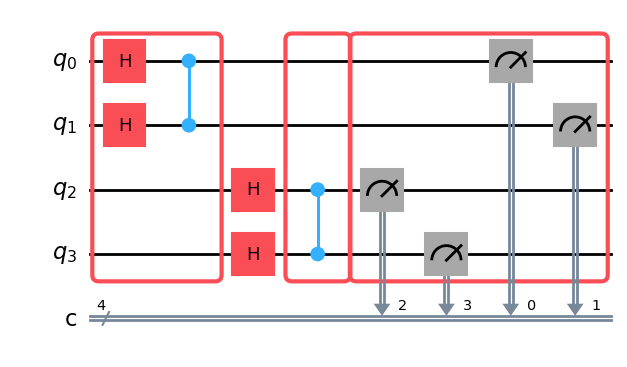

In [13]:
bpm2 = generate_boxing_pass_manager(remove_barriers="finally")

tqc2 = bpm2.run(qc)
tqc2.draw('mpl')

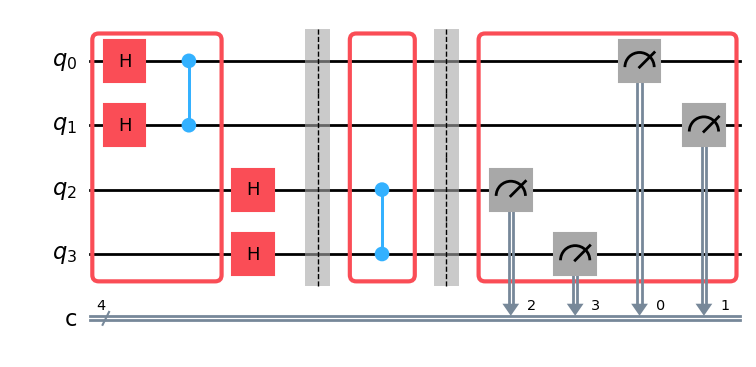

In [14]:
bpm2 = generate_boxing_pass_manager(remove_barriers="never")

tqc2 = bpm2.run(qc)
tqc2.draw('mpl')